<a href="https://colab.research.google.com/github/castroirene28/Machine-Learning-Project-1/blob/main/Copy_of_Country_Population_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Preview
   Country  GDP_Billion  Tourists_Million  Internet_Users_Million  \
0      USA        25000                80                     310   
1   Canada         2200                22                      35   
2    Japan         5000                32                     118   
3  Germany         4300                39                      79   
4   France         3000                90                      65   

   Population_Million  Popularity_Score  
0                 331                95  
1                  38                78  
2                 126                90  
3                  83                88  
4                  67                91  

Missing Values
Country                   0
GDP_Billion               0
Tourists_Million          0
Internet_Users_Million    0
Population_Million        0
Popularity_Score          0
dtype: int64


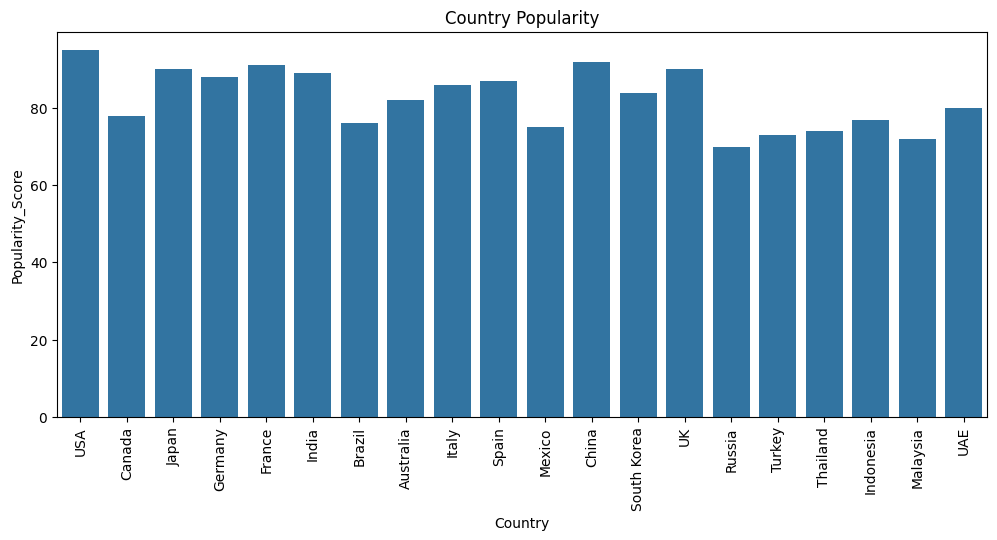

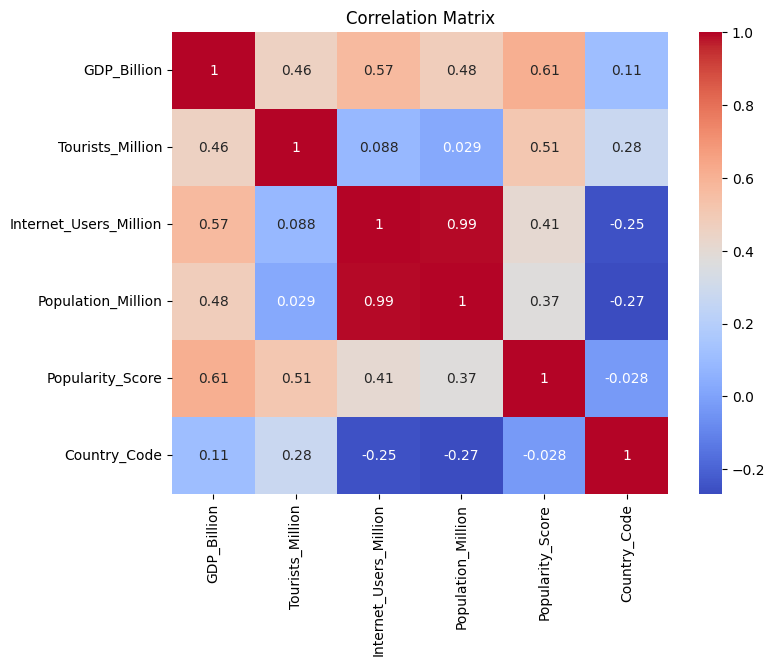


Model Evaluation
MAE : 4.09
MSE : 18.96
RMSE: 4.35
R2 Score: 0.73

Feature Importance
                  Feature  Importance
0             GDP_Billion    0.657837
1        Tourists_Million    0.124098
3      Population_Million    0.081741
2  Internet_Users_Million    0.078532
4            Country_Code    0.057791


/tmp/ipykernel_17690/1278788330.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


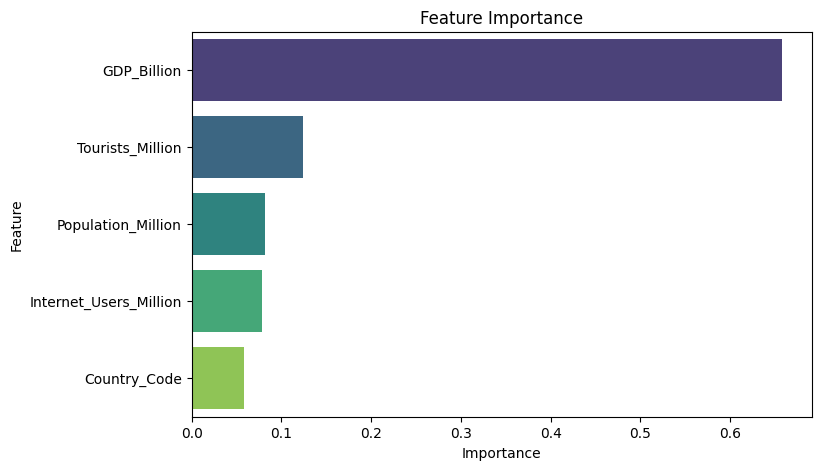


Actual vs Predicted
   Actual  Predicted
0      95     89.455
1      77     75.290
2      73     77.015
3      78     83.105


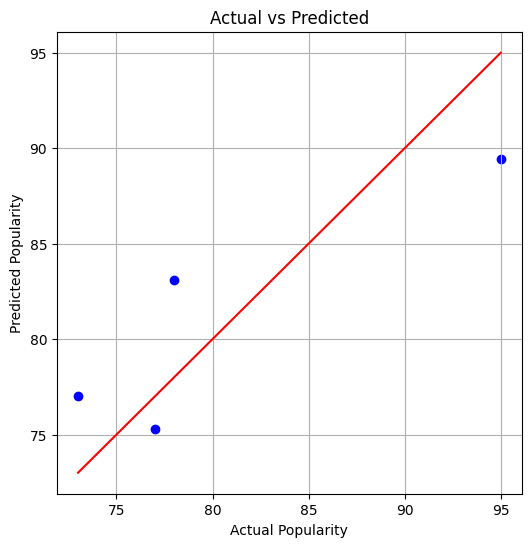


Predicted Popularity Score: 89.24

Project Completed Successfully!


In [ ]:

# Machine Learning Engineering Project on Country Popularity Prediction

# Install (if needed)
# !pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create Dataset


data = {
    "Country":[
        "USA","Canada","Japan","Germany","France",
        "India","Brazil","Australia","Italy","Spain",
        "Mexico","China","South Korea","UK","Russia",
        "Turkey","Thailand","Indonesia","Malaysia","UAE"
    ],
    "GDP_Billion":[25000,2200,5000,4300,3000,
                   3500,1800,1600,2100,1500,
                   1400,18000,1800,3200,1800,
                   900,550,1200,400,500],
    "Tourists_Million":[80,22,32,39,90,
                        18,6,9,65,83,
                        45,63,17,40,24,
                        50,40,16,26,22],
    "Internet_Users_Million":[310,35,118,79,65,
                              850,150,24,50,45,
                              95,1050,50,67,124,
                              68,57,200,30,10],
    "Population_Million":[331,38,126,83,67,
                          1400,214,26,60,47,
                          128,1412,52,68,144,
                          85,70,275,33,10],
    "Popularity_Score":[95,78,90,88,91,
                        89,76,82,86,87,
                        75,92,84,90,70,
                        73,74,77,72,80]
}

df = pd.DataFrame(data)

print("\nDataset Preview")
print(df.head())


# Data Cleaning


print("\nMissing Values")
print(df.isnull().sum())

# Feature Engineering


encoder = LabelEncoder()
df["Country_Code"] = encoder.fit_transform(df["Country"])


# Exploratory Data Analysis

plt.figure(figsize=(12,5))
sns.barplot(x="Country", y="Popularity_Score", data=df)
plt.xticks(rotation=90)
plt.title("Country Popularity")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.drop("Country", axis=1).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# Prepare Data


X = df.drop(["Country","Popularity_Score"], axis=1)
y = df["Popularity_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Train Model


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


# Prediction


predictions = model.predict(X_test)


# Evaluation

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nModel Evaluation")
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="viridis"
)
plt.title("Feature Importance")
plt.show()


# Actual vs Predicted


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

print("\nActual vs Predicted")
print(comparison)

plt.figure(figsize=(6,6))
plt.scatter(
    comparison["Actual"],
    comparison["Predicted"],
    color="blue"
)

plt.plot(
    [comparison["Actual"].min(), comparison["Actual"].max()],
    [comparison["Actual"].min(), comparison["Actual"].max()],
    color="red"
)

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

# ------------------------------------------
# Step 11: Predict New Country Popularity
# ------------------------------------------

new_country = pd.DataFrame({
    "GDP_Billion":[4500],
    "Tourists_Million":[55],
    "Internet_Users_Million":[120],
    "Population_Million":[95],
    "Country_Code":[5]
})

prediction = model.predict(new_country)

print("\nPredicted Popularity Score:", round(prediction[0],2))

print("\nProject Completed Successfully!")